In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# **Set Seed**

In [1]:
import random
import numpy as np
import tensorflow as tf
import os

SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(SEED)


2026-06-22 07:59:30.638241: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782115170.850968      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782115170.908771      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782115171.374963      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782115171.375006      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782115171.375032      58 computation_placer.cc:177] computation placer alr

In [2]:
import os
import shutil
import random

# Paths
DATASET_PATH = "/kaggle/input/datasets/mohammadamireshraghi/blood-cell-cancer-all-4class/Blood cell Cancer [ALL]"   # adjust if different
OUTPUT_PATH = "/kaggle/working/train1"

# Classes in dataset
classes = [
    "Benign",
    "[Malignant] Pre-B",
    "[Malignant] Pro-B",
    "[Malignant] early Pre-B"
]
os.makedirs(OUTPUT_PATH, exist_ok=True)

for cls in classes:
    src_folder = os.path.join(DATASET_PATH, cls)
    dst_folder = os.path.join(OUTPUT_PATH, cls.replace(" ", "_"))
    os.makedirs(dst_folder, exist_ok=True)

    images = [f for f in os.listdir(src_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    for img in images:
        src_path = os.path.join(src_folder, img)
        dst_path = os.path.join(dst_folder, img)

        # Copy image
        shutil.copy2(src_path, dst_path)

    print(f"Class {cls}: {len(images)} images copied.")

print("All class images copied into train folder.")

Class Benign: 512 images copied.
Class [Malignant] Pre-B: 955 images copied.
Class [Malignant] Pro-B: 796 images copied.
Class [Malignant] early Pre-B: 979 images copied.
All class images copied into train folder.


In [3]:
train_dir = "/kaggle/working/train1"

# **Data Visualization**

Classes: ['[Malignant]_early_Pre-B', '[Malignant]_Pro-B', '[Malignant]_Pre-B', 'Benign']


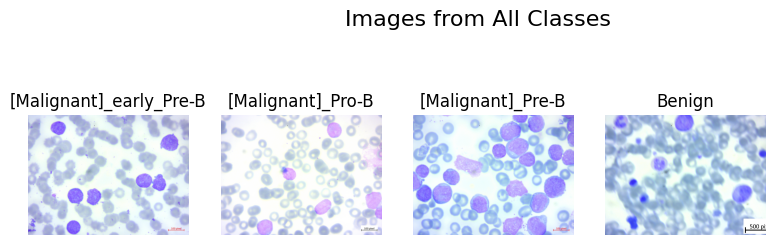

In [4]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import random

classes = os.listdir(train_dir)
print("Classes:", classes)

# Show one random image from each class
plt.figure(figsize=(12, 6))
for i, cls in enumerate(classes):
    cls_path = os.path.join(train_dir, cls)

    # Pick a random image from that class
    img_name = random.choice(os.listdir(cls_path))
    img_path = os.path.join(cls_path, img_name)

    # Read image
    img = mpimg.imread(img_path)

    # Plot
    plt.subplot(2, 5, i+1)  # 2 rows, 5 columns
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.suptitle("Images from All Classes", fontsize=16)
plt.show()

/tmp/ipykernel_58/744780496.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="label", y="count", data=df, palette=palette)


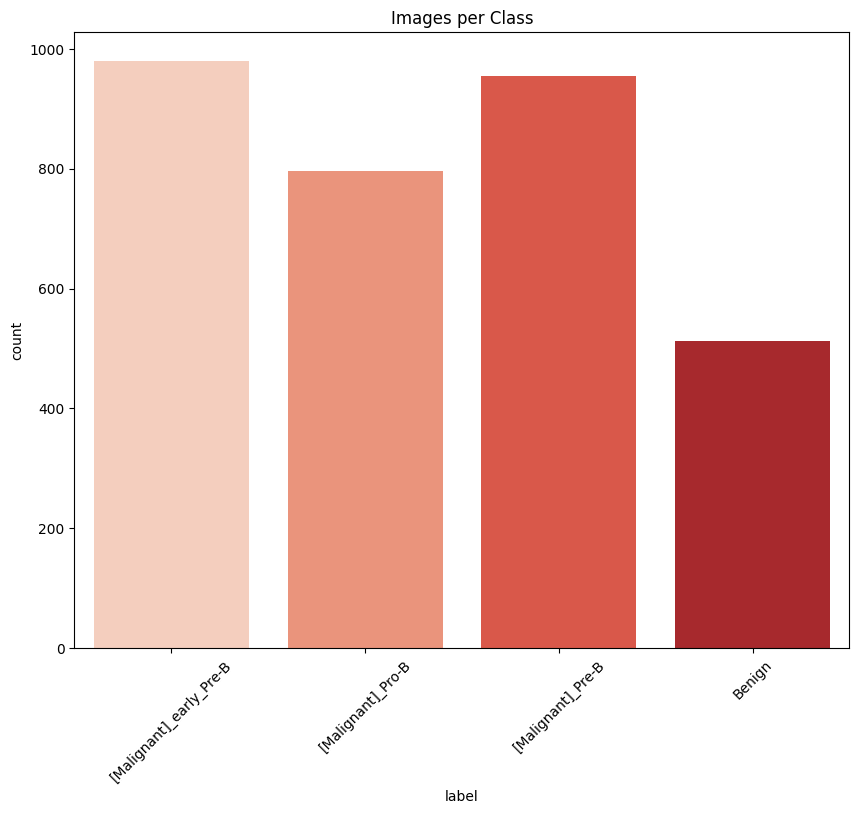

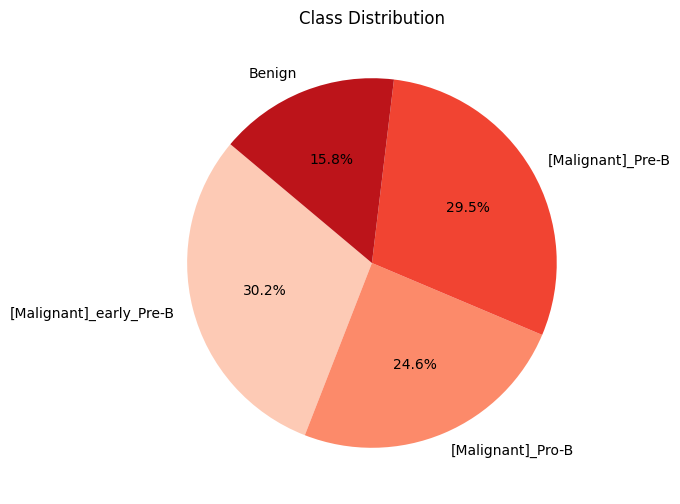

In [5]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Count images per class
df = pd.DataFrame([(cls, len(os.listdir(os.path.join(train_dir, cls))))
                   for cls in os.listdir(train_dir)], columns=["label", "count"])

# Choose a blue-purple palette
palette = sns.color_palette("Reds", len(df))

# Bar chart
plt.figure(figsize=(10, 8))
sns.barplot(x="label", y="count", data=df, palette=palette)
plt.xticks(rotation=45)
plt.title("Images per Class")
plt.show()

# Pie chart
df.set_index("label")["count"].plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=140,
    figsize=(6, 6),
    colors=palette
)
plt.title("Class Distribution")
plt.ylabel("")
plt.show()

# **Encode labels**

In [6]:
import os
import pandas as pd
from PIL import Image
import numpy as np

all_images = []
all_labels = []

for cls in os.listdir(train_dir):
    cls_path = os.path.join(train_dir, cls)
    for img_name in os.listdir(cls_path):
        all_images.append(os.path.join(cls_path, img_name))
        all_labels.append(cls)

df = pd.DataFrame({"image_path": all_images, "label": all_labels})

# Preview
df.head()

,image_path,label
0,/kaggle/working/train1/[Malignant]_early_Pre-B...,[Malignant]_early_Pre-B
1,/kaggle/working/train1/[Malignant]_early_Pre-B...,[Malignant]_early_Pre-B
2,/kaggle/working/train1/[Malignant]_early_Pre-B...,[Malignant]_early_Pre-B
3,/kaggle/working/train1/[Malignant]_early_Pre-B...,[Malignant]_early_Pre-B
4,/kaggle/working/train1/[Malignant]_early_Pre-B...,[Malignant]_early_Pre-B


# **train_test_split**

In [8]:
test_df = df.groupby('label_num', group_keys=False).apply(
    lambda x: x.sample(100, random_state=SEED)
)

remaining_df = df.drop(test_df.index)

valid_df = remaining_df.groupby('label_num', group_keys=False).apply(
    lambda x: x.sample(100, random_state=SEED)
)

train_df = remaining_df.drop(valid_df.index)

# optional shuffle for full reproducibility
train_df = train_df.sample(frac=1, random_state=SEED).reset_index(drop=True)
valid_df = valid_df.sample(frac=1, random_state=SEED).reset_index(drop=True)
test_df = test_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

# ============================================================
# INFO
# ============================================================

print("Train size:", train_df.shape)
print("Validation size:", valid_df.shape)
print("Test size:", test_df.shape)

Train size: (2442, 3)
Validation size: (400, 3)
Test size: (400, 3)


/tmp/ipykernel_58/2144433403.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test_df = df.groupby('label_num', group_keys=False).apply(
/tmp/ipykernel_58/2144433403.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  valid_df = remaining_df.groupby('label_num', group_keys=False).apply(


In [9]:
print(train_df['label_num'].value_counts())

label_num
3    779
1    755
2    596
0    312
Name: count, dtype: int64


In [11]:
train_dir_aug = "train_aug"  # folder for augmented training images
os.makedirs(train_dir_aug, exist_ok=True)

for cls in train_df["label"].unique():
    os.makedirs(os.path.join(train_dir_aug, cls), exist_ok=True)

# **Oversampling on Train set**

In [13]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from PIL import Image
import numpy as np
import os

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.05,
    height_shift_range=0.05,
    shear_range=0.05,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

target_count = 750  # desired max images per class

for cls in train_df["label"].unique():
    cls_train_images = train_df[train_df['label'] == cls]["image_path"].tolist()
    cls_aug_path = os.path.join(train_dir_aug, cls)

    # Copy original images to augmented folder
    for img_path in cls_train_images:
        img_name = os.path.basename(img_path)
        dest_path = os.path.join(cls_aug_path, img_name)
        if not os.path.exists(dest_path):
            Image.open(img_path).convert("RGB").save(dest_path)

    # Now calculate current count AFTER copying originals
    current_count = len(os.listdir(cls_aug_path))

    needed = target_count - current_count
    if needed <= 0:
        print(f"Skipping {cls}: {current_count} images already present.")
        continue

    print(f"Augmenting {cls}: generating {needed} images...")

    img_index = 0
    cls_aug_images = [os.path.join(cls_aug_path, f) for f in os.listdir(cls_aug_path)]
    for _ in range(needed):
        img_path = cls_aug_images[img_index % len(cls_train_images)]
        img = np.expand_dims(np.array(Image.open(img_path).convert("RGB")), axis=0)
        aug_iter = datagen.flow(img, batch_size=1,
                                save_to_dir=cls_aug_path,
                                save_prefix="aug",
                                save_format="jpg")
        next(aug_iter)
        img_index += 1

# After all classes, print final counts
print("\n✅ Data augmentation completed.\n")
for cls in os.listdir(train_dir_aug):
    count = len(os.listdir(os.path.join(train_dir_aug, cls)))
    print(f"{cls}: {count} images")

Augmenting [Malignant]_Pro-B: generating 1 images...
Skipping [Malignant]_Pre-B: 755 images already present.
Skipping [Malignant]_early_Pre-B: 779 images already present.
Augmenting Benign: generating 7 images...

✅ Data augmentation completed.

[Malignant]_early_Pre-B: 779 images
[Malignant]_Pro-B: 750 images
[Malignant]_Pre-B: 755 images
Benign: 750 images


# **Data Augmentation**

In [15]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input

batch_size = 32
img_size = (224, 224)

# Training augmentation
tr_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.05,
    horizontal_flip=True,
    vertical_flip=False,
    fill_mode='nearest'
)

# Test/validation generator (no augmentation)
ts_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

# Convert 'label_num' columns to string type for flow_from_dataframe with class_mode='sparse'
train_df_aug['label_num'] = train_df_aug['label_num'].astype(str)
valid_df['label_num'] = valid_df['label_num'].astype(str)
test_df['label_num'] = test_df['label_num'].astype(str)

train_gen = tr_gen.flow_from_dataframe(train_df_aug, x_col='image_path', y_col='label_num',
                                       target_size=img_size, class_mode='sparse',
                                       color_mode='rgb', shuffle=True, batch_size=batch_size,seed=SEED)

valid_gen = ts_gen.flow_from_dataframe(valid_df, x_col='image_path', y_col='label_num',
                                       target_size=img_size, class_mode='sparse',
                                       color_mode='rgb', shuffle=True, batch_size=batch_size,seed=SEED)

test_gen = ts_gen.flow_from_dataframe(test_df, x_col='image_path', y_col='label_num',
                                      target_size=img_size, class_mode='sparse',
                                      color_mode='rgb', shuffle=False, batch_size=batch_size,seed=SEED)

Found 3034 validated image filenames belonging to 4 classes.
Found 400 validated image filenames belonging to 4 classes.
Found 400 validated image filenames belonging to 4 classes.


# **MobileNetV3Small**

In [16]:
from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import CosineDecay

def create_efficientnet_simple(input_shape=(224,224,3), num_classes=4):
    inputs = Input(shape=input_shape)

    # Pretrained  without top layers
    base = MobileNetV3Small(weights='imagenet', include_top=False, input_tensor=inputs)

    # Freeze most layers except last 50 for fine-tuning
    for layer in base.layers[:-50]:
        layer.trainable = False

    # Base output
    x = base.output
    x = GlobalAveragePooling2D()(x)

    # Fully connected layers
    x = Dense(512, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)

    x = Dense(256, activation='relu')(x)
    x = Dropout(0.4)(x)

    # Output layer
    outputs = Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs)


# Learning rate schedule (cosine decay)
lr_schedule = CosineDecay(
    initial_learning_rate=3e-4,  # starting LR
    decay_steps=1000,            # steps for one cycle
    alpha=1e-6                   # final LR fraction
)

# Create and compile model
model = create_efficientnet_simple(num_classes=4)
model.compile(
    optimizer=Adam(learning_rate=lr_schedule),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

I0000 00:00:1782115535.114881      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782115535.117538      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv (Conv2D)       │ (None, 112, 112,  │        432 │ rescaling[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_bn             │ (None, 112, 112,  │         64 │ conv[0][0]        │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 112, 112,  │          0 │ conv_bn[0][0]     │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 113, 113,  │          0 │ activation[0][0]  │
│ (ZeroPadding2D)     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 56, 56,    │        144 │ expanded_conv_de… │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 56, 56,    │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 56, 56,    │          0 │ expanded_conv_de… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 16)  │          0 │ re_lu[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 8)   │        136 │ expanded_conv_sq… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 8)   │          0 │ expanded_conv_sq… │
│ (ReLU)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 16)  │        144 │ expanded_conv_sq… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1, 1, 16)  │          0 │ expanded_conv_sq… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 1, 1, 16)  │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 1, 1, 16)  │          0 │ re_lu_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 56, 56,    │          0 │ re_lu[0][0],      │
│ (Multiply)          │ 16)               │            │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 56, 56,    │        256 │ expanded_conv_sq

 Total params: 1,368,948 (5.22 MB)

 Trainable params: 1,165,388 (4.45 MB)

 Non-trainable params: 203,560 (795.16 KB)

In [17]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True, verbose=1),
    ModelCheckpoint("best_model.h5", monitor='val_accuracy', save_best_only=True, verbose=1)
]

history = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=10,
    callbacks= callbacks,
    verbose=1
)

Epoch 1/10


I0000 00:00:1782115560.383285     165 service.cc:152] XLA service 0x7db4d0112840 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782115560.383340     165 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782115560.383346     165 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782115562.461371     165 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1782115575.119610     165 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 527ms/step - accuracy: 0.7077 - loss: 0.8267
Epoch 1: val_accuracy improved from None to 0.75250, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
95/95 ━━━━━━━━━━━━━━━━━━━━ 91s 695ms/step - accuracy: 0.8586 - loss: 0.3899 - val_accuracy: 0.7525 - val_loss: 0.6876
Epoch 2/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step - accuracy: 0.9691 - loss: 0.0868
Epoch 2: val_accuracy improved from 0.75250 to 0.78250, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
95/95 ━━━━━━━━━━━━━━━━━━━━ 42s 444ms/step - accuracy: 0.9733 - loss: 0.0792 - val_accuracy: 0.7825 - val_loss: 0.6103
Epoch 3/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step - accuracy: 0.9807 - loss: 0.0545
Epoch 3: val_accuracy improved from 0.78250 to 0.90500, saving model to best_model.h5


...


Epoch 4: finished saving model to best_model.h5
95/95 ━━━━━━━━━━━━━━━━━━━━ 41s 436ms/step - accuracy: 0.9888 - loss: 0.0350 - val_accuracy: 0.9350 - val_loss: 0.1927
Epoch 5/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - accuracy: 0.9911 - loss: 0.0249
Epoch 5: val_accuracy improved from 0.93500 to 0.95750, saving model to best_model.h5



Epoch 5: finished saving model to best_model.h5
95/95 ━━━━━━━━━━━━━━━━━━━━ 41s 435ms/step - accuracy: 0.9891 - loss: 0.0283 - val_accuracy: 0.9575 - val_loss: 0.1238
Epoch 6/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - accuracy: 0.9922 - loss: 0.0352
Epoch 6: val_accuracy improved from 0.95750 to 0.97750, saving model to best_model.h5



Epoch 6: finished saving model to best_model.h5
95/95 ━━━━━━━━━━━━━━━━━━━━ 41s 431ms/step - accuracy: 0.9918 - loss: 0.0303 - val_accuracy: 0.9775 - val_loss: 0.0912
Epoch 7/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - accuracy: 0.9931 - loss: 0.0184
Epoch 7: val_accuracy improved from 0.97750 to 0.98500, saving model to best_model.h5



Epoch 7: finished saving model to best_model.h5
95/95 ━━━━━━━━━━━━━━━━━━━━ 41s 435ms/step - accuracy: 0.9931 - loss: 0.0205 - val_accuracy: 0.9850 - val_loss: 0.0632
Epoch 8/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step - accuracy: 0.9959 - loss: 0.0107
Epoch 8: val_accuracy did not improve from 0.98500
95/95 ━━━━━━━━━━━━━━━━━━━━ 41s 432ms/step - accuracy: 0.9947 - loss: 0.0126 - val_accuracy: 0.9850 - val_loss: 0.0574
Epoch 9/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - accuracy: 0.9938 - loss: 0.0189
Epoch 9: val_accuracy did not improve from 0.98500
95/95 ━━━━━━━━━━━━━━━━━━━━ 41s 429ms/step - accuracy: 0.9944 - loss: 0.0159 - val_accuracy: 0.9850 - val_loss: 0.0446
Epoch 10/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - accuracy: 0.9948 - loss: 0.0189
Epoch 10: val_accuracy improved from 0.98500 to 0.99000, saving model to best_model.h5



Epoch 10: finished saving model to best_model.h5
95/95 ━━━━━━━━━━━━━━━━━━━━ 41s 430ms/step - accuracy: 0.9957 - loss: 0.0165 - val_accuracy: 0.9900 - val_loss: 0.0379
Restoring model weights from the end of the best epoch: 10.


In [18]:
# Evaluate on the test generator
loss, accuracy = model.evaluate(test_gen, verbose=1)

print(f"Final Test Accuracy: {accuracy*100:.2f}%")
print(f"Final Test Loss: {loss:.4f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 336ms/step - accuracy: 1.0000 - loss: 0.0101
Final Test Accuracy: 100.00%
Final Test Loss: 0.0101


In [19]:
from tensorflow.keras.models import load_model
model.load_weights('best_model.h5')
best_model = model

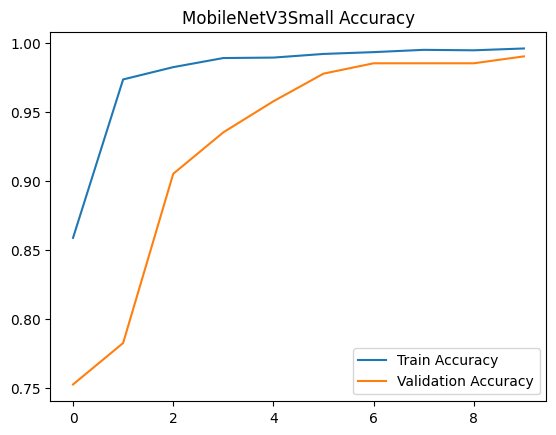

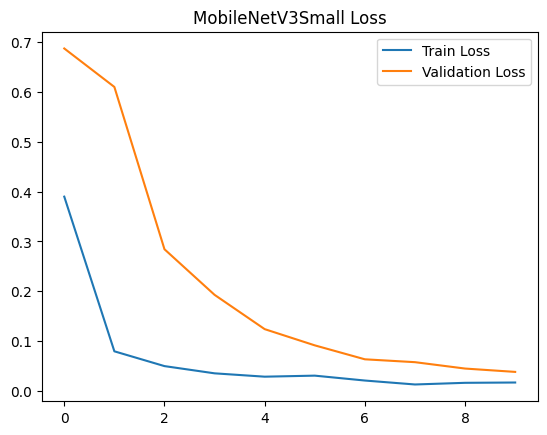

In [20]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("MobileNetV3Small Accuracy")
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("MobileNetV3Small Loss")
plt.show()

13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 330ms/step

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       100
           2       1.00      1.00      1.00       100
           3       1.00      1.00      1.00       100

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



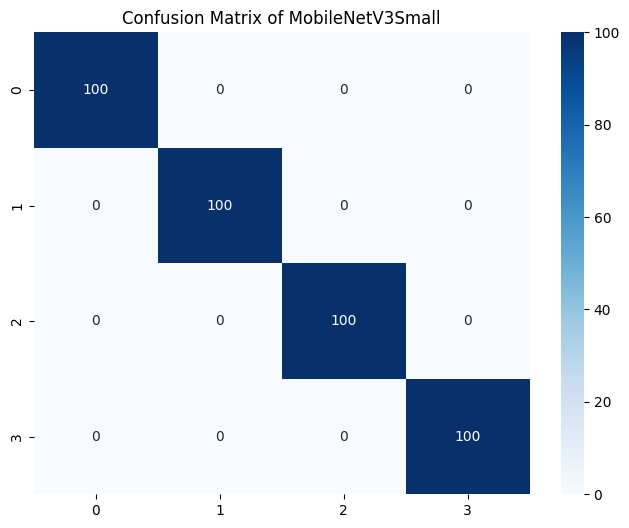

In [22]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# True labels from test generator
y_true = test_gen.classes

# Predictions
y_pred = np.argmax(model.predict(test_gen), axis=1) #argmax finds the index of the largest value in an array

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=list(test_gen.class_indices.keys())))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_gen.class_indices.keys(),
            yticklabels=test_gen.class_indices.keys())
plt.title("Confusion Matrix of MobileNetV3Small")
plt.show()

# **Compute Flops,Measure Inference Time,Memory Consumption**

I0000 00:00:1782116498.496918      58 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 2
I0000 00:00:1782116498.497133      58 single_machine.cc:374] Starting new session
I0000 00:00:1782116498.512319      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782116498.513936      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Instructions for updating:
This API was designed for TensorFlow v1. See https://www.tensorflow.org/guide/migrate for instructions on how to migrate your code to TensorFlow v2.


Instructions for updating:
This API was designed for TensorFlow v1. See https://www.tensorflow.org/guide/migrate for instructions on how to migrate your code to TensorFlow v2.



=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes          
-show_name_regexes          .*
-hide_name_regexes          
-account_displayed_op_only  true
-select                     float_ops
-output                     stdout:

==================Model Analysis Report======================

Doc:
op: The nodes are operation kernel type, such as MatMul, Conv2D. Graph nodes belonging to the same type are aggregated together.
flops: Number of float operations. Note: Please read the implementation for th

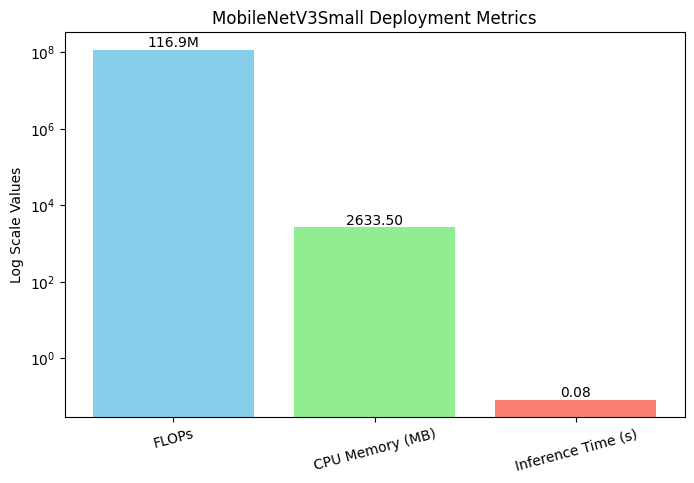

In [29]:
import tensorflow as tf
import time
import numpy as np
import psutil
import os
import matplotlib.pyplot as plt
from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2

# -----------------------------
# 1. Compute FLOPs
# -----------------------------
def get_flops(model):
    input_shape = [1] + list(model.input_shape[1:])  # batch size 1
    concrete_func = tf.function(lambda x: model(x))
    concrete_func = concrete_func.get_concrete_function(
        tf.TensorSpec(input_shape, model.inputs[0].dtype)
    )
    frozen_func = convert_variables_to_constants_v2(concrete_func)
    graph_def = frozen_func.graph.as_graph_def()

    with tf.Graph().as_default() as graph:
        tf.graph_util.import_graph_def(graph_def, name="")
        run_meta = tf.compat.v1.RunMetadata()
        opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()
        flops = tf.compat.v1.profiler.profile(graph=graph, run_meta=run_meta, cmd='op', options=opts)
        return flops.total_float_ops

flops = get_flops(model)

# -----------------------------
# 2. Measure inference time
# -----------------------------
x_sample = np.random.rand(1, 224, 224, 3).astype(np.float32)
_ = model.predict(x_sample)  # warm-up

start_time = time.time()
_ = model.predict(x_sample)
inference_time = time.time() - start_time

# -----------------------------
# 3. Measure CPU and GPU memory
# -----------------------------
process = psutil.Process(os.getpid())
cpu_memory = process.memory_info().rss / (1024 ** 2)  # MB

gpu_memory = 0
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        # Construct the correct device string, e.g., 'GPU:0' from '/physical_device:GPU:0'
        device_name_for_memory_info = f"{gpu.device_type}:{gpu.name.split(':')[-1]}"
        details = tf.config.experimental.get_memory_info(device_name_for_memory_info)
        gpu_memory = details['peak'] / (1024 ** 2)  # MB

# -----------------------------
# 4. Prepare metrics for plotting
# -----------------------------
metrics = ['FLOPs', 'CPU Memory (MB)', 'Inference Time (s)']
values = [flops, cpu_memory, inference_time]

if gpu_memory > 0:
    metrics.append('GPU Memory (MB)')
    values.append(gpu_memory)

# Use log scale for better visualization
plt.figure(figsize=(8,5))
bars = plt.bar(metrics, values, color=['skyblue', 'lightgreen', 'salmon', 'orchid'])
plt.yscale('log')
plt.title("MobileNetV3Small Deployment Metrics")
plt.ylabel("Log Scale Values")
plt.xticks(rotation=15)

# Annotate bars with readable values
for i, bar in enumerate(bars):
    height = bar.get_height()
    if metrics[i] == 'FLOPs':
        plt.text(bar.get_x() + bar.get_width()/2, height, f'{height/1e6:.1f}M', ha='center', va='bottom')
    else:
        plt.text(bar.get_x() + bar.get_width()/2, height, f'{height:.2f}', ha='center', va='bottom')

plt.show()

# **ECE**

13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 333ms/step
Expected Calibration Error (ECE): 0.0087


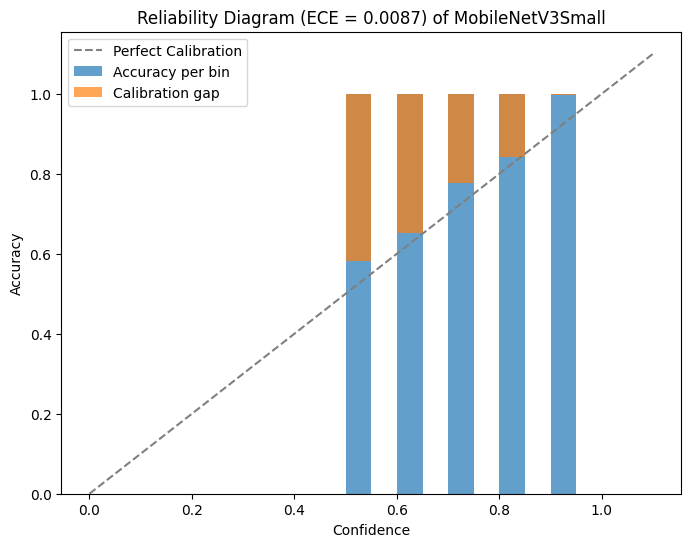

In [28]:
import numpy as np
import matplotlib.pyplot as plt

def compute_ece(probs, labels, n_bins=10):
    """
    Compute Expected Calibration Error (ECE)
    
    probs: array of shape (num_samples, num_classes), predicted probabilities
    labels: array of shape (num_samples,), true class indices
    n_bins: number of bins for calibration
    """
    labels = np.array(labels)  # ensure labels is a numpy array
    confidences = np.max(probs, axis=1)  # predicted probability of the predicted class
    predictions = np.argmax(probs, axis=1)
    
    bin_edges = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    bin_acc = []
    bin_conf = []
    bin_sizes = []

    for i in range(n_bins):
        lower, upper = bin_edges[i], bin_edges[i+1]
        mask = (confidences > lower) & (confidences <= upper)
        bin_size = np.sum(mask)
        
        if bin_size > 0:
            acc = np.mean((predictions[mask] == labels[mask]))
            conf = np.mean(confidences[mask])
            ece += (bin_size / len(labels)) * abs(acc - conf)
        else:
            acc, conf = 0, 0
        
        bin_acc.append(acc)
        bin_conf.append(conf)
        bin_sizes.append(bin_size)
    
    return ece, bin_acc, bin_conf, bin_sizes

# Convert predictions to probabilities if not already
y_probs = model.predict(test_gen)  # shape: (num_samples, num_classes)
y_true_array = np.array(test_gen.classes)  # convert to numpy array

# Compute ECE
ece, bin_acc, bin_conf, bin_sizes = compute_ece(y_probs, y_true_array, n_bins=10)
print(f"Expected Calibration Error (ECE): {ece:.4f}")

# Plot reliability diagram
plt.figure(figsize=(8,6))
plt.plot([0,1.1], [0,1.1], linestyle='--', color='gray', label='Perfect Calibration')
plt.bar(np.arange(10)/10 + 0.05/2, bin_acc, width=0.05, alpha=0.7, label='Accuracy per bin')
plt.bar(np.arange(10)/10 + 0.05/2, np.array(bin_conf)-np.array(bin_acc), bottom=bin_acc, width=0.05, alpha=0.7, label='Calibration gap')

plt.xlabel("Confidence")
plt.ylabel("Accuracy")
plt.title(f"Reliability Diagram (ECE = {ece:.4f}) of MobileNetV3Small")
plt.legend()
plt.show()